# Week 5 – Linear Regression: my extra experiments
COS30018 Lab 5, section 4. The provided `Linear_Regression.ipynb` trains sklearn's `LinearRegression` on California Housing and checks the MSE on the **same** data it trained on. I wanted to understand what's going on underneath, so here I:

* **A.** fit the tiny 3-house example from the lab sheet (area → price) and plot the regression line
* **B.** implement **gradient descent from scratch** with the cost function $J(w)=\frac{1}{2}\sum_i (y(x^i)-y^i)^2$ and update rule $w = w - \alpha \nabla_w J(w)$ from the sheet, check it matches sklearn, and play with the learning rate $\alpha$
* **C.** do a proper **train/test split** (so the error is measured on houses the model has never seen) – on sklearn's built-in diabetes dataset
* **D.** the same train/test split on **California Housing** (needs internet to download the dataset)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import os

os.makedirs("figures", exist_ok=True)   # plots get saved here for my worklog
np.random.seed(42)
plt.rcParams["figure.dpi"] = 110

## A. The 3-house example from the lab sheet
| Area (sq.ft) | Price ($1000s) |
|---|---|
| 3456 | 600 |
| 2089 | 395 |
| 1416 | 232 |

In [2]:
area  = np.array([3456, 2089, 1416], dtype=float)
price = np.array([600, 395, 232], dtype=float)

X = area.reshape(-1, 1)          # sklearn wants a 2D array: (n_samples, n_features)
lin = LinearRegression().fit(X, price)
m, b = lin.coef_[0], lin.intercept_
print(f"slope m     = {m:.4f}  ($1000s per sq.ft)")
print(f"intercept b = {b:.2f}")
print(f"=> price = {m:.4f} * area + ({b:.2f})")

new_house = 2500
print(f"\nPredicted price for a {new_house} sq.ft house: ${lin.predict([[new_house]])[0]:.1f}k")

slope m     = 0.1759  ($1000s per sq.ft)
intercept b = 0.76
=> price = 0.1759 * area + (0.76)

Predicted price for a 2500 sq.ft house: $440.6k


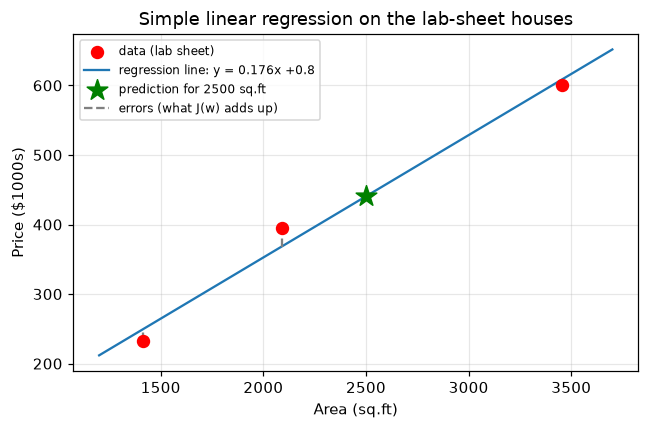

In [3]:
xs = np.linspace(1200, 3700, 100)
plt.figure(figsize=(6, 4))
plt.scatter(area, price, color="red", s=60, zorder=3, label="data (lab sheet)")
plt.plot(xs, lin.predict(xs.reshape(-1, 1)), label=f"regression line: y = {m:.3f}x {b:+.1f}")
for xi, yi, yhat in zip(area, price, lin.predict(X)):
    plt.vlines(xi, min(yi, yhat), max(yi, yhat), colors="grey", linestyles="--", linewidth=1.5)   # the errors J(w) adds up
plt.scatter([new_house], lin.predict([[new_house]]), marker="*", s=200, color="green", zorder=4, label="prediction for 2500 sq.ft")
plt.xlabel("Area (sq.ft)"); plt.ylabel("Price ($1000s)")
plt.title("Simple linear regression on the lab-sheet houses")
plt.plot([], [], "--", color="grey", label="errors (what J(w) adds up)")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("figures/5_1_toy_regression_line.png", dpi=150)
plt.show()

## B. Gradient descent from scratch
Model: $y(x) = w_0 + w_1 x$. Cost: $J(w)=\frac{1}{2}\sum_i (y(x^i)-y^i)^2$.

Gradients: $\frac{\partial J}{\partial w_0} = \sum_i (y(x^i)-y^i)$ and $\frac{\partial J}{\partial w_1} = \sum_i (y(x^i)-y^i)\,x^i$ (the ½ cancels the 2 from the square – that's why the sheet adds it).

**Problem I hit:** with the raw areas (~1000s) the gradient for $w_1$ is huge and GD blew up straight away (cost ~1e205 after just 20 iterations with α = 0.01) unless α was tiny. Fix = **standardise** the feature first ($z = (x-\mu)/\sigma$), run GD, then convert the weights back to the original units.

In [4]:
def gradient_descent(x, y, alpha, n_iters=500):
    w0, w1 = 0.0, 0.0                      # start from zero weights
    history = []
    for _ in range(n_iters):
        y_hat = w0 + w1 * x
        err = y_hat - y
        J = 0.5 * np.sum(err ** 2)          # cost from the lab sheet
        history.append(J)
        grad_w0 = np.sum(err)
        grad_w1 = np.sum(err * x)
        w0 -= alpha * grad_w0               # w = w - alpha * dJ/dw
        w1 -= alpha * grad_w1
    return w0, w1, np.array(history)

# 1) what happens on the raw (unscaled) feature
with np.errstate(over="ignore", invalid="ignore"):
    _, _, hist_raw = gradient_descent(area, price, alpha=0.01, n_iters=20)
print("raw feature, alpha=0.01 -> cost after 20 its:", hist_raw[-1])

# 2) standardise first
mu, sigma = area.mean(), area.std()
z = (area - mu) / sigma
w0, w1, hist = gradient_descent(z, price, alpha=0.1, n_iters=500)

# convert back:  w0 + w1*(x-mu)/sigma  =  (w0 - w1*mu/sigma) + (w1/sigma)*x
m_gd = w1 / sigma
b_gd = w0 - w1 * mu / sigma
print(f"\ngradient descent : m = {m_gd:.4f}, b = {b_gd:.2f}, final cost J = {hist[-1]:.2f}")
print(f"sklearn          : m = {m:.4f}, b = {b:.2f}")
print("match?", np.allclose([m_gd, b_gd], [m, b], atol=1e-3))

raw feature, alpha=0.01 -> cost after 20 its: 2.7452193800765648e+205

gradient descent : m = 0.1759, b = 0.76, final cost J = 555.32
sklearn          : m = 0.1759, b = 0.76
match? True


**Learning-rate experiment** (the sheet says too big overshoots, too small is slow – wanted to see it). With standardised $x$ and 3 points, GD only converges for $\alpha < 2/3$ here.

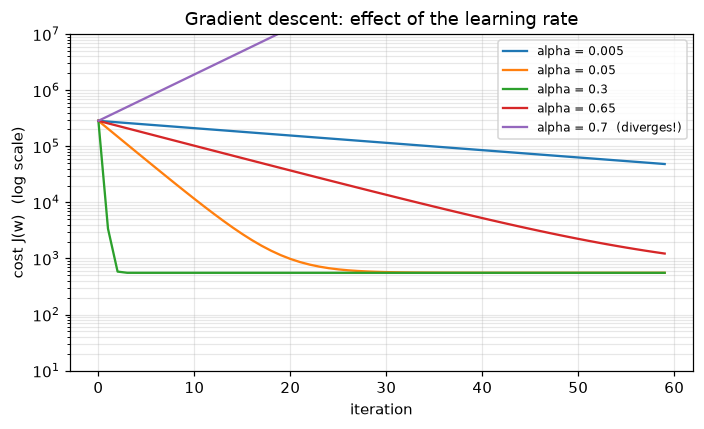

In [5]:
plt.figure(figsize=(6.5, 4))
for alpha in [0.005, 0.05, 0.3, 0.65, 0.7]:
    with np.errstate(over="ignore", invalid="ignore"):
        _, _, h = gradient_descent(z, price, alpha=alpha, n_iters=60)
    label = f"alpha = {alpha}"
    if not np.isfinite(h[-1]) or h[-1] > h[0]:
        label += "  (diverges!)"
    plt.semilogy(h, label=label)
plt.xlabel("iteration"); plt.ylabel("cost J(w)  (log scale)")
plt.title("Gradient descent: effect of the learning rate")
plt.ylim(1e1, 1e7)
plt.legend(fontsize=8); plt.grid(alpha=0.3, which="both"); plt.tight_layout()
plt.savefig("figures/5_2_learning_rate.png", dpi=150)
plt.show()

What I see: α = 0.005 is still crawling down after 60 steps, α = 0.05 and 0.3 converge nicely (0.3 almost instantly), at 0.65 it zig-zags (cost goes down slowly while the weights overshoot back and forth) and at 0.7 it **diverges** – the cost grows every step. Exactly the overshooting picture from the lab sheet.

## C. Proper train/test split (diabetes dataset – ships with sklearn, no download)
The provided notebook computes the MSE on the training data, which is a bit optimistic. Holding out 20% as a test set gives an honest number.

In [6]:
from sklearn.datasets import load_diabetes
diab = load_diabetes()
print(diab.data.shape, "->", diab.feature_names)

Xtr, Xte, ytr, yte = train_test_split(diab.data, diab.target, test_size=0.2, random_state=42)
model = LinearRegression().fit(Xtr, ytr)

for name, Xs, ys in [("train", Xtr, ytr), ("test ", Xte, yte)]:
    pred = model.predict(Xs)
    print(f"{name}: MSE = {mean_squared_error(ys, pred):8.1f} | R^2 = {r2_score(ys, pred):.3f}")

(442, 10) -> ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
train: MSE =   2868.5 | R^2 = 0.528
test : MSE =   2900.2 | R^2 = 0.453


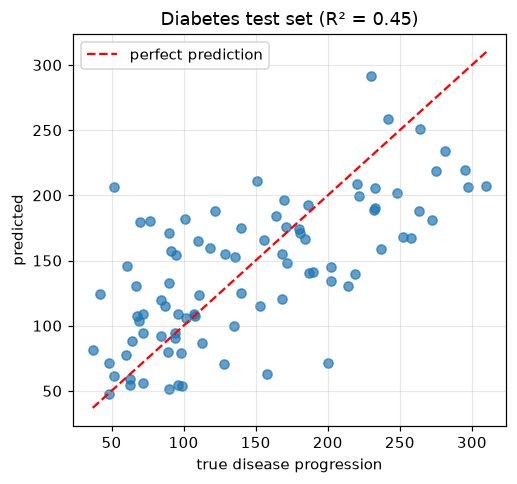

In [7]:
pred = model.predict(Xte)
plt.figure(figsize=(4.8, 4.5))
plt.scatter(yte, pred, alpha=0.7)
lims = [min(yte.min(), pred.min()), max(yte.max(), pred.max())]
plt.plot(lims, lims, "r--", label="perfect prediction")
plt.xlabel("true disease progression"); plt.ylabel("predicted")
plt.title(f"Diabetes test set (R² = {r2_score(yte, pred):.2f})")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("figures/5_3_diabetes_pred_vs_true.png", dpi=150)
plt.show()

## D. Same thing on California Housing
`fetch_california_housing()` downloads the data the first time (needs internet – works in Colab / on my laptop).
I wrapped it in try/except so the notebook still runs end-to-end without internet.

In [8]:
try:
    from sklearn.datasets import fetch_california_housing
    cal = fetch_california_housing()
    X_tr, X_te, y_tr, y_te = train_test_split(cal.data, cal.target, test_size=0.2, random_state=42)
    cal_model = LinearRegression().fit(X_tr, y_tr)
    for name, Xs, ys in [("train", X_tr, y_tr), ("test ", X_te, y_te)]:
        p = cal_model.predict(Xs)
        print(f"{name}: MSE = {mean_squared_error(ys, p):.4f} | R^2 = {r2_score(ys, p):.4f}")
    print()
    for f, c in sorted(zip(cal.feature_names, cal_model.coef_), key=lambda t: -abs(t[1])):
        print(f"{f:>10}: {c:+.4f}")
    CAL_OK = True
except Exception as e:
    print("Couldn't download California Housing here:", type(e).__name__, e)
    print("-> run this notebook in Colab / locally to get this section's results")
    CAL_OK = False

/usr/local/lib/python3.11/dist-packages/sklearn/datasets/_base.py:1521: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


Couldn't download California Housing here: URLError <urlopen error Tunnel connection failed: 403 Forbidden>
-> run this notebook in Colab / locally to get this section's results


In [9]:
if CAL_OK:
    p = cal_model.predict(X_te)
    plt.figure(figsize=(4.8, 4.5))
    plt.scatter(y_te, p, s=4, alpha=0.3)
    plt.plot([0, 5], [0, 5], "r--", label="perfect prediction")
    plt.xlabel("true median house value ($100k)"); plt.ylabel("predicted")
    plt.title(f"California Housing test set (R² = {r2_score(y_te, p):.2f})")
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig("figures/5_4_california_pred_vs_true.png", dpi=150)
    plt.show()
else:
    print("skipped (no dataset)")

skipped (no dataset)


## Takeaways
* sklearn's `LinearRegression` and my own gradient descent land on the same line – sklearn just solves it directly (least squares) instead of iterating.
* Feature scaling matters a lot for gradient descent.
* The learning rate really does decide between slow / good / diverging.
* Always evaluate on data the model didn't train on – training error alone hides overfitting (here the gap is small because linear regression is a simple model).